In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/seg_train.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/data")

with zipfile.ZipFile("/content/drive/MyDrive/seg_test.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
train_path = "/content/data/seg_train"
test_path = "/content/data/seg_test"

In [5]:
img_size = (150,150)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150,150,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(6, activation='softmax')
])

/tmp/ipykernel_20707/2366101080.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 333s 932ms/step - accuracy: 0.7753 - loss: 0.6078 - val_accuracy: 0.8735 - val_loss: 0.3416
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 376s 915ms/step - accuracy: 0.8301 - loss: 0.4662 - val_accuracy: 0.8767 - val_loss: 0.3235
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 351s 999ms/step - accuracy: 0.8407 - loss: 0.4243 - val_accuracy: 0.8785 - val_loss: 0.3247
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 342s 976ms/step - accuracy: 0.8523 - loss: 0.3987 - val_accuracy: 0.8906 - val_loss: 0.2922
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 350s 998ms/step - accuracy: 0.8542 - loss: 0.3988 - val_accuracy: 0.8799 - val_loss: 0.3047


In [8]:
test_loss, test_acc = model.evaluate(test_ds)

print("Final Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 57s 603ms/step - accuracy: 0.8937 - loss: 0.2918
Final Test Accuracy: 0.893666684627533


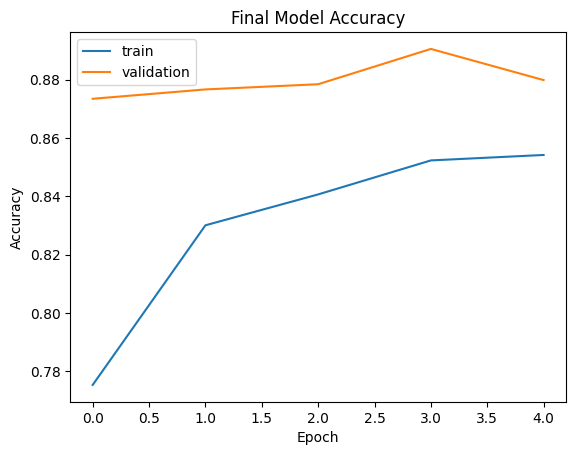

In [9]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.title("Final Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

In [10]:
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred = np.argmax(model.predict(test_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

94/94 ━━━━━━━━━━━━━━━━━━━━ 69s 697ms/step
              precision    recall  f1-score   support

   buildings       0.13      0.14      0.13       437
      forest       0.16      0.16      0.16       474
     glacier       0.18      0.19      0.19       553
    mountain       0.15      0.13      0.14       525
         sea       0.18      0.19      0.19       510
      street       0.16      0.15      0.16       501

    accuracy                           0.16      3000
   macro avg       0.16      0.16      0.16      3000
weighted avg       0.16      0.16      0.16      3000



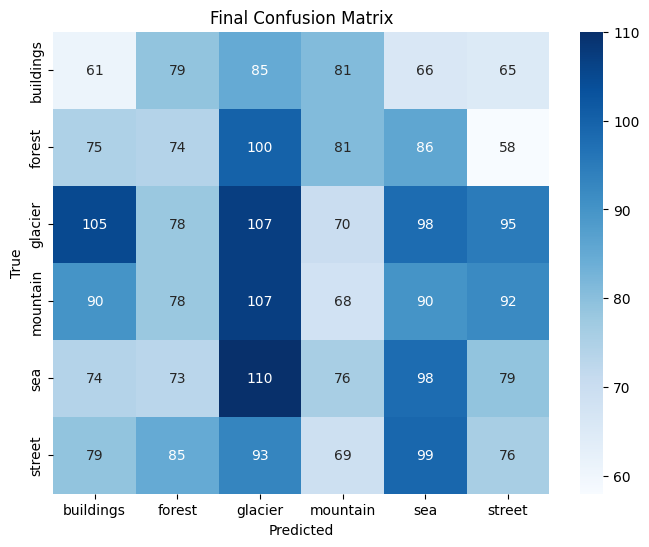

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Final Confusion Matrix")

plt.show()